# Assignment : GANs with 2D Synthetic Data
--- 
*Department of Data Science, UOH*
---

### Step 1: Creating & Visualizing a 2D Sine Wave Dataset


Device in use: mps


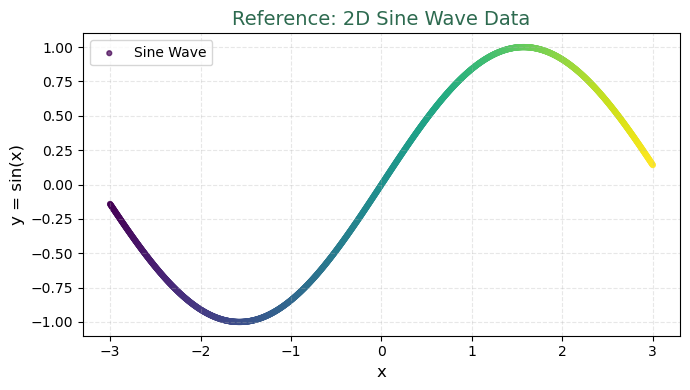

In [1]:
# Step 1A: Environment setup & data generation
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Device selection (Apple MPS or CPU)
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Device in use: {device}")
# For reproducibility
np.random.seed(7)
torch.manual_seed(7)

# Generate sine wave data
N = 2048
x = np.linspace(-3, 3, N)
y = np.sin(x)
data = np.column_stack((x, y)).astype(np.float32)

# Visualization with a fresh color palette
plt.figure(figsize=(7, 4))
colors = cm.viridis(np.linspace(0, 1, N))
plt.scatter(x, y, c=colors, s=12, alpha=0.7, label="Sine Wave")
plt.title("Reference: 2D Sine Wave Data", fontsize=14, color="#2d6a4f")
plt.xlabel("x", fontsize=12)
plt.ylabel("y = sin(x)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [2]:
# Step 1B: Define Generator & Discriminator
import torch.nn as nn
from termcolor import colored

# Generator: maps noise to 2D point
class Generator(nn.Module):
    def __init__(self, latent_dim=2, hidden_dim=32):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, 2)
        )
    def forward(self, z):
        return self.model(z)

# Discriminator: classifies real/fake
class Discriminator(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

# Instantiate models
latent_dim = 2
G = Generator(latent_dim).to(device)
D = Discriminator().to(device)

# Print model summaries with color
print(colored("Generator Architecture:", 'green', attrs=['bold']))
print(G)
print(colored("Discriminator Architecture:", 'blue', attrs=['bold']))
print(D)

Generator Architecture:
Generator(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)
Discriminator Architecture:
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


Epoch    1 D_loss=1.2970 G_loss=0.6930
Epoch  100 D_loss=1.3822 G_loss=0.7111
Epoch  200 D_loss=1.4196 G_loss=0.7381
Epoch  300 D_loss=1.1350 G_loss=1.3922
Epoch  400 D_loss=1.3815 G_loss=0.7012
Epoch  500 D_loss=1.3869 G_loss=0.6831
Epoch  600 D_loss=1.3853 G_loss=0.7071
Epoch  700 D_loss=1.3894 G_loss=0.6961
Epoch  800 D_loss=1.3768 G_loss=0.6913
Epoch  900 D_loss=1.3843 G_loss=0.6847
Epoch 1000 D_loss=1.3861 G_loss=0.7026
Training complete.


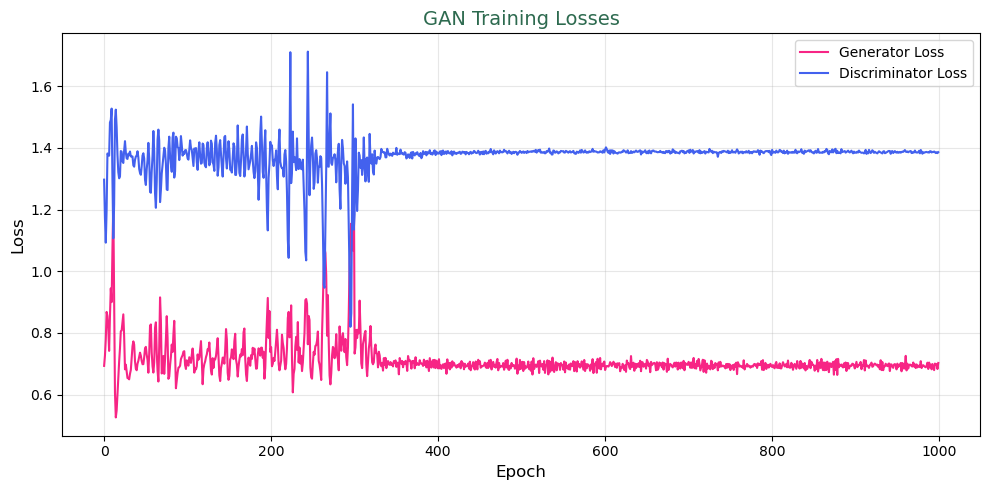

In [3]:
# Step 1C: DataLoader & Training Loop 
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from termcolor import colored

# Prepare DataLoader
real_data = torch.tensor(data, dtype=torch.float32)
batch_size = 128
train_loader = DataLoader(TensorDataset(real_data), batch_size=batch_size, shuffle=True)

# Hyperparameters
num_epochs = 1000
lr = 0.001
criterion = nn.BCELoss()
optimizer_G = torch.optim.Adam(G.parameters(), lr=lr)
optimizer_D = torch.optim.Adam(D.parameters(), lr=lr)

G_losses, D_losses = [], []

for epoch in range(1, num_epochs+1):
    for real_batch, in train_loader:
        real_batch = real_batch.to(device)
        b_size = real_batch.size(0)
        # Labels
        real_labels = torch.ones(b_size, 1, device=device)
        fake_labels = torch.zeros(b_size, 1, device=device)
        # --- Train Discriminator ---
        optimizer_D.zero_grad()
        real_pred = D(real_batch)
        real_loss = criterion(real_pred, real_labels)
        z = torch.randn(b_size, latent_dim, device=device)
        fake_data = G(z)
        fake_pred = D(fake_data.detach())
        fake_loss = criterion(fake_pred, fake_labels)
        D_loss = real_loss + fake_loss
        D_loss.backward()
        optimizer_D.step()
        # --- Train Generator ---
        optimizer_G.zero_grad()
        z = torch.randn(b_size, latent_dim, device=device)
        gen_data = G(z)
        gen_pred = D(gen_data)
        G_loss = criterion(gen_pred, real_labels)
        G_loss.backward()
        optimizer_G.step()
    G_losses.append(G_loss.item())
    D_losses.append(D_loss.item())
    if epoch % 100 == 0 or epoch == 1:
        print(colored(f"Epoch {epoch:4d}", 'cyan'), colored(f"D_loss={D_loss.item():.4f}", 'magenta'), colored(f"G_loss={G_loss.item():.4f}", 'yellow'))

print(colored("Training complete.", 'green', attrs=['bold']))

# Stylish loss curves
plt.figure(figsize=(10, 5))
plt.plot(G_losses, label='Generator Loss', color='#f72585')
plt.plot(D_losses, label='Discriminator Loss', color='#4361ee')
plt.title("GAN Training Losses", fontsize=14, color="#2d6a4f")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

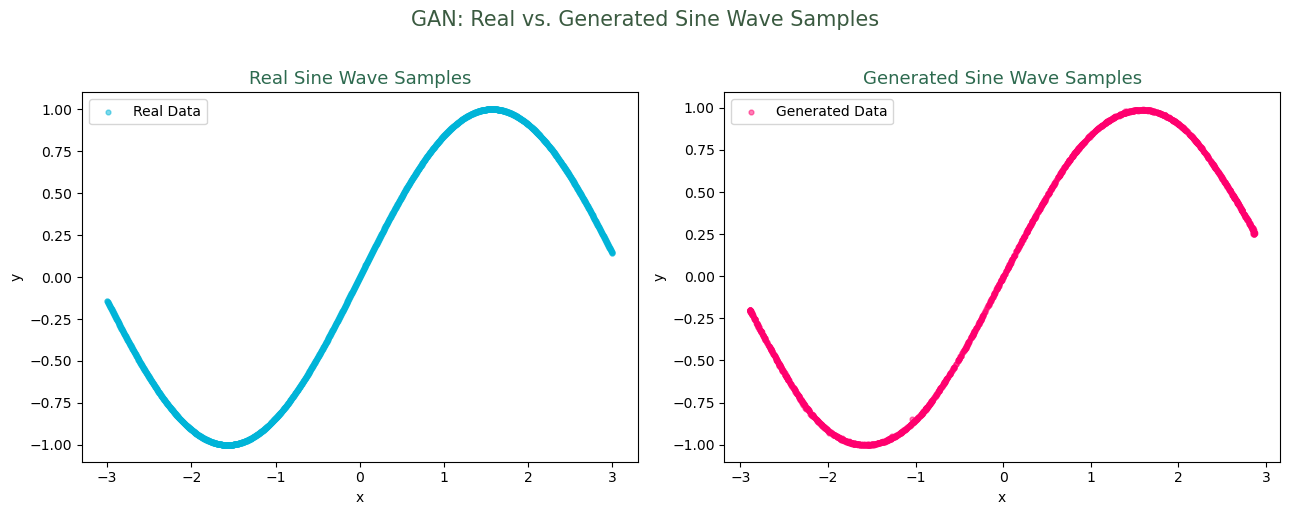

In [4]:
# Step 1D: Generate & Compare Samples 
num_samples = 2048
with torch.no_grad():
    z = torch.randn(num_samples, latent_dim, device=device)
    fake_samples = G(z).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(data[:, 0], data[:, 1], s=12, alpha=0.5, color='#00b4d8', label="Real Data")
axes[0].set_title("Real Sine Wave Samples", fontsize=13, color="#2d6a4f")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

axes[1].scatter(fake_samples[:, 0], fake_samples[:, 1], s=12, alpha=0.5, color='#ff006e', label="Generated Data")
axes[1].set_title("Generated Sine Wave Samples", fontsize=13, color="#2d6a4f")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()

plt.suptitle("GAN: Real vs. Generated Sine Wave Samples", fontsize=15, color="#3a5a40", y=1.02)
plt.tight_layout()
plt.show()

## Step 2: Building & Visualizing a 2D Spiral Dataset

*Department of Data Science, UOH*
---

In this part, we'll create a 2D spiral dataset—a classic challenge for generative models. The spiral's complex structure will help us test how well our GAN can learn and reproduce non-linear patterns. Let's visualize the real spiral data before training!


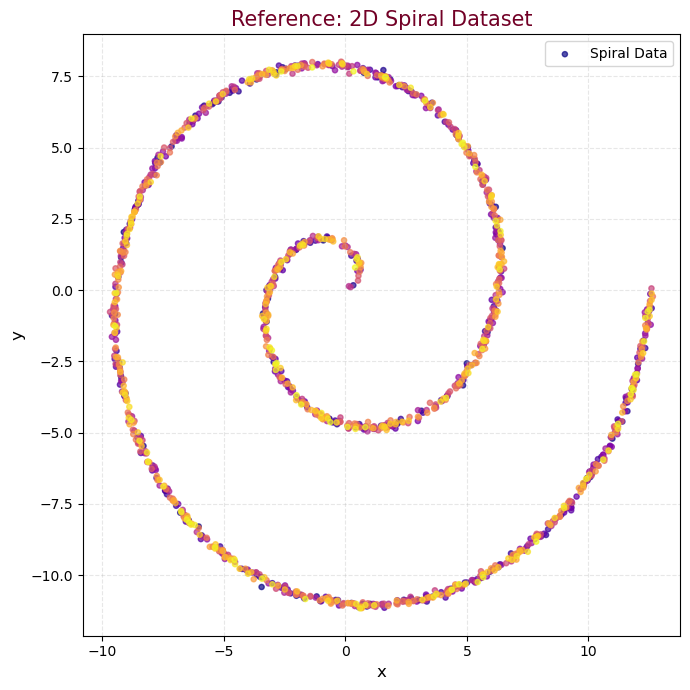

In [5]:
# Step 2A: Generate & Visualize Spiral Data 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def generate_spiral(n_points=1500, noise=0.07):
    theta = np.sqrt(np.random.rand(n_points)) * 4 * np.pi
    r = theta
    x1 = r * np.cos(theta) + np.random.normal(0, noise, n_points)
    x2 = r * np.sin(theta) + np.random.normal(0, noise, n_points)
    return np.column_stack((x1, x2))

spiral_data = generate_spiral()

# Modern visualization with a fresh palette
plt.figure(figsize=(7, 7))
colors = cm.plasma(np.linspace(0, 1, spiral_data.shape[0]))
plt.scatter(spiral_data[:, 0], spiral_data[:, 1], c=colors, alpha=0.7, s=14, label="Spiral Data")
plt.title("Reference: 2D Spiral Dataset", fontsize=15, color="#720026")
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 3: Designing GAN Architectures for Spiral Data
---


In [6]:
# Step 3A: GAN Architectures for Spiral Data 
import torch
import torch.nn as nn

# Generator: noise -> 2D spiral point
class Generator(nn.Module):
    def __init__(self, z_dim=2, hidden_dim=64, out_dim=2):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, out_dim)
        )
    def forward(self, z):
        return self.model(z)

# Discriminator: 2D point -> real/fake
class Discriminator(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

In [7]:
# Step 3B: Training GAN on Spiral Data 
import torch.optim as optim

# Hyperparameters
z_dim = 2
lr = 1e-3
batch_size = 128
num_epochs = 4000
device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')

# DataLoader
spiral_tensor = torch.tensor(spiral_data, dtype=torch.float32)
dataset = torch.utils.data.TensorDataset(spiral_tensor)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Model setup
G = Generator(z_dim=z_dim).to(device)
D = Discriminator().to(device)
loss_fn = nn.BCELoss()
g_optim = optim.Adam(G.parameters(), lr=lr)
d_optim = optim.Adam(D.parameters(), lr=lr)

d_losses, g_losses = [], []
for epoch in range(num_epochs):
    for real_batch, in dataloader:
        real_batch = real_batch.to(device)
        b_size = real_batch.size(0)
        # Labels
        real_labels = torch.ones(b_size, 1, device=device)
        fake_labels = torch.zeros(b_size, 1, device=device)
        # --- Train Discriminator ---
        z = torch.randn(b_size, z_dim, device=device)
        fake_data = G(z)
        d_real = D(real_batch)
        d_fake = D(fake_data.detach())
        d_loss = loss_fn(d_real, real_labels) + loss_fn(d_fake, fake_labels)
        d_optim.zero_grad()
        d_loss.backward()
        d_optim.step()
        # --- Train Generator ---
        z = torch.randn(b_size, z_dim, device=device)
        fake_data = G(z)
        d_fake = D(fake_data)
        g_loss = loss_fn(d_fake, real_labels)
        g_optim.zero_grad()
        g_loss.backward()
        g_optim.step()
    d_losses.append(d_loss.item())
    g_losses.append(g_loss.item())
    if (epoch+1) % 200 == 0:
        print(f"Epoch {epoch+1}: D_loss={d_loss.item():.4f}, G_loss={g_loss.item():.4f}")

print("Training Complete.")

Epoch 200: D_loss=1.3253, G_loss=0.6388
Epoch 400: D_loss=1.3776, G_loss=0.6672
Epoch 600: D_loss=1.3825, G_loss=0.6862
Epoch 800: D_loss=1.3731, G_loss=0.7094
Epoch 1000: D_loss=1.4098, G_loss=0.7144
Epoch 1200: D_loss=1.3418, G_loss=0.7866
Epoch 1400: D_loss=1.3100, G_loss=0.7603
Epoch 1600: D_loss=1.3318, G_loss=0.8443
Epoch 1800: D_loss=1.3203, G_loss=0.7143
Epoch 2000: D_loss=1.3216, G_loss=0.7581
Epoch 2200: D_loss=1.3407, G_loss=0.7897
Epoch 2400: D_loss=1.3382, G_loss=0.8319
Epoch 2600: D_loss=1.2959, G_loss=0.7543
Epoch 2800: D_loss=1.3555, G_loss=0.8536
Epoch 3000: D_loss=1.3501, G_loss=0.7395
Epoch 3200: D_loss=1.3936, G_loss=0.7033
Epoch 3400: D_loss=1.3711, G_loss=0.7414
Epoch 3600: D_loss=1.3458, G_loss=0.8541
Epoch 3800: D_loss=1.3498, G_loss=0.7669
Epoch 4000: D_loss=1.3692, G_loss=0.7022
Training Complete.


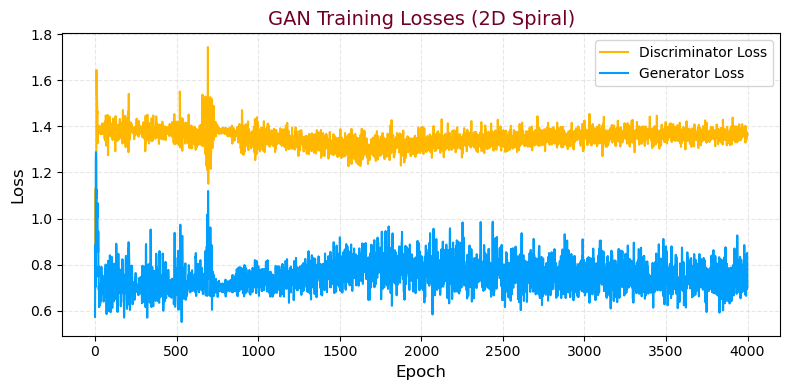

In [8]:
# Step 3C: Visualize GAN Training Losses
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(d_losses, label="Discriminator Loss", color="#ffb700")
plt.plot(g_losses, label="Generator Loss", color="#009ffd")
plt.title("GAN Training Losses (2D Spiral)", fontsize=14, color="#720026")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

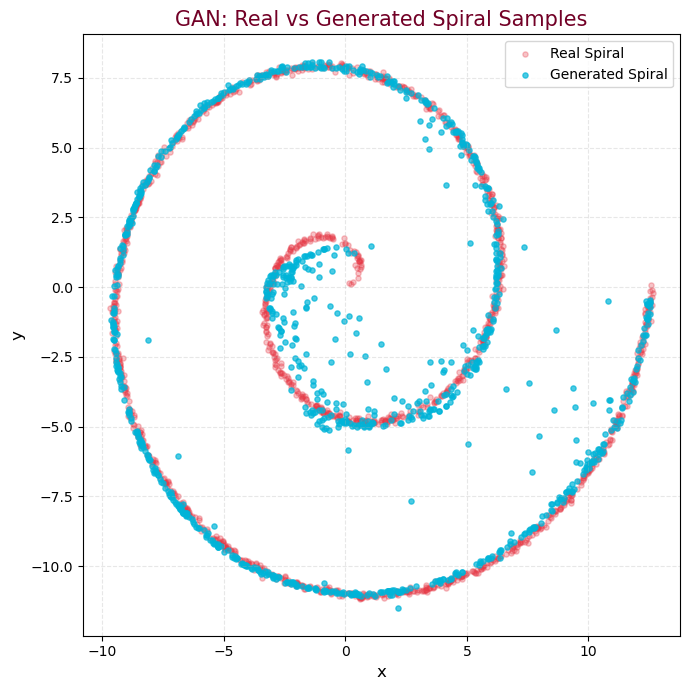

In [9]:
# Step 3D: Compare Real vs Generated Spiral Samples
with torch.no_grad():
    z = torch.randn(1000, z_dim, device=device)
    fake_spiral = G(z).cpu().numpy()

plt.figure(figsize=(7, 7))
plt.scatter(spiral_data[:, 0], spiral_data[:, 1], color="#e63946", alpha=0.3, s=14, label="Real Spiral")
plt.scatter(fake_spiral[:, 0], fake_spiral[:, 1], color="#00b4d8", alpha=0.7, s=14, label="Generated Spiral")
plt.title("GAN: Real vs Generated Spiral Samples", fontsize=15, color="#720026")
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4: BloodMNIST DCGAN (Part 2.1)

*Department of Data Science, UOH*
---

Moving from synthetic 2D data to real biomedical images, we now train a DCGAN on the **BloodMNIST** dataset (MedMNIST v2). BloodMNIST contains 28x28 RGB microscope images of eight peripheral-blood cell types. We use the standard DCGAN recipe (strided-conv generator with ReLU + Tanh, strided-conv discriminator with LeakyReLU), Adam with the classic (0.5, 0.999) betas, and BCE loss.


Device in use: mps
BloodMNIST train size: 11959
Image shape: torch.Size([3, 28, 28])
Classes: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}


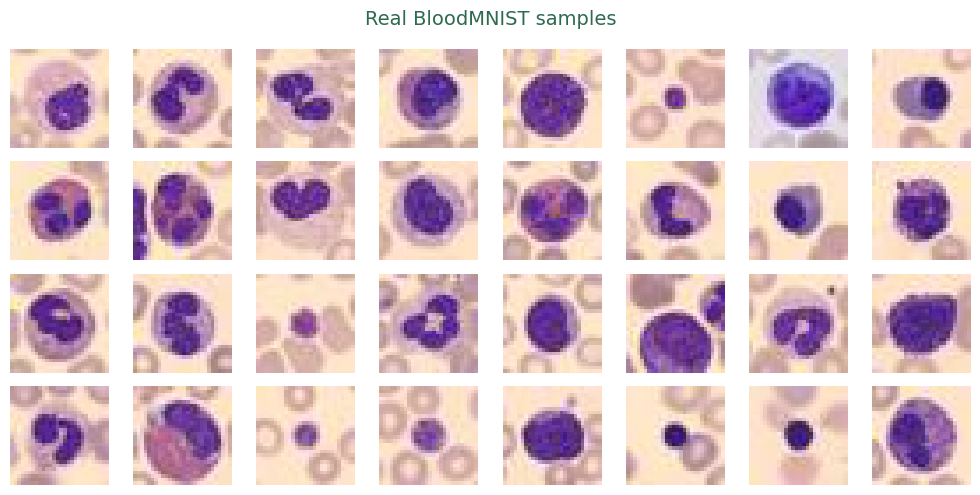

In [10]:
# Step 4A: Load BloodMNIST & build a DataLoader
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from termcolor import colored

# Install medmnist if not present (Colab) - pip install medmnist
try:
    from medmnist import BloodMNIST, INFO
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "medmnist", "-q"])
    from medmnist import BloodMNIST, INFO

import torchvision.transforms as T
from torch.utils.data import DataLoader

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(colored(f"Device in use: {device}", 'cyan', attrs=['bold']))
np.random.seed(7)
torch.manual_seed(7)

# DCGAN uses Tanh output, so normalise inputs to [-1, 1]
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])

train_ds = BloodMNIST(split="train", download=True, transform=transform)
print(colored(f"BloodMNIST train size: {len(train_ds)}", 'green'))
print(colored(f"Image shape: {train_ds[0][0].shape}", 'green'))
print(colored(f"Classes: {INFO['bloodmnist']['label']}", 'magenta'))

batch_size = 128
blood_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)

# Peek at a grid of real samples
real_batch, _ = next(iter(blood_loader))
fig, axes = plt.subplots(4, 8, figsize=(10, 5))
for ax, img in zip(axes.flat, real_batch):
    ax.imshow(((img.permute(1, 2, 0).numpy() + 1) / 2).clip(0, 1))
    ax.axis('off')
plt.suptitle("Real BloodMNIST samples", fontsize=14, color="#2d6a4f")
plt.tight_layout()
plt.show()


In [11]:
# Step 4B: DCGAN Generator & Discriminator for 28x28 RGB images
import torch.nn as nn

nz = 100   # latent dim
nc = 3     # channels
ngf = 64   # generator feature maps
ndf = 64   # discriminator feature maps

class DCGenerator(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=3):
        super().__init__()
        # 1x1 -> 7x7 -> 14x14 -> 28x28
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*4, 7, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(z)

class DCDiscriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*2, 1, 7, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).view(-1, 1)

# DCGAN weight init
def dcgan_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G_blood = DCGenerator(nz, ngf, nc).to(device)
D_blood = DCDiscriminator(nc, ndf).to(device)
G_blood.apply(dcgan_init)
D_blood.apply(dcgan_init)

print(colored("DCGAN Generator:", 'green', attrs=['bold']))
print(G_blood)
print(colored("DCGAN Discriminator:", 'blue', attrs=['bold']))
print(D_blood)


DCGAN Generator:
DCGenerator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
)
DCGAN Discriminator:
DCDiscriminator(
  (net): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, 

Epoch   1 D_loss=1.0079 G_loss=2.6707
Epoch   2 D_loss=0.9646 G_loss=1.6494
Epoch   4 D_loss=1.0799 G_loss=2.2874
Epoch   6 D_loss=1.0820 G_loss=3.4145
Epoch   8 D_loss=1.0520 G_loss=0.6562
Epoch  10 D_loss=1.6304 G_loss=0.2357
Epoch  12 D_loss=1.0479 G_loss=1.5645
Epoch  14 D_loss=0.4594 G_loss=1.5491
Epoch  16 D_loss=0.7477 G_loss=1.4990
Epoch  18 D_loss=0.9139 G_loss=1.3309
Epoch  20 D_loss=0.7806 G_loss=1.6155
Epoch  22 D_loss=0.9460 G_loss=1.7785
Epoch  24 D_loss=0.8716 G_loss=3.7708
Epoch  26 D_loss=0.3752 G_loss=2.6138
Epoch  28 D_loss=0.3608 G_loss=2.0463
Epoch  30 D_loss=0.8982 G_loss=1.0201
BloodMNIST DCGAN training complete.


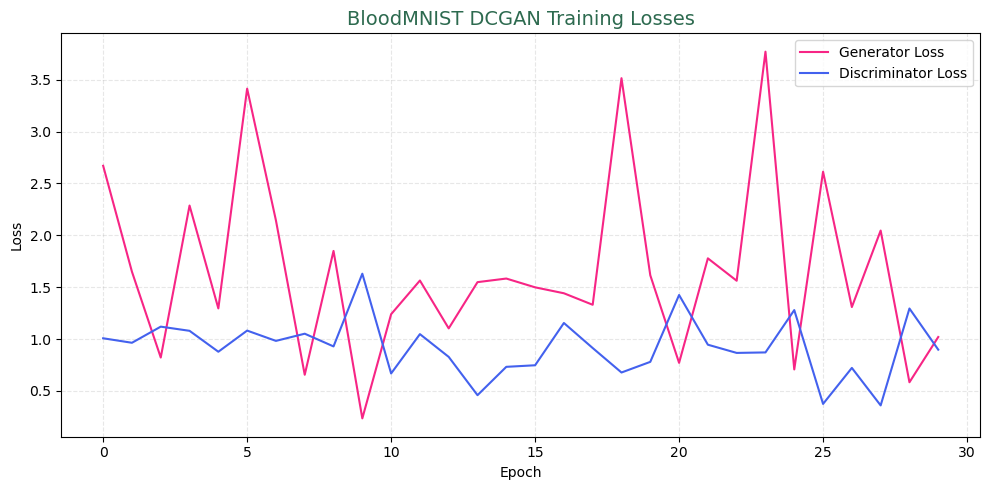

In [12]:
# Step 4C: Train BloodMNIST DCGAN
import torch.optim as optim

criterion = nn.BCELoss()
optG = optim.Adam(G_blood.parameters(), lr=2e-4, betas=(0.5, 0.999))
optD = optim.Adam(D_blood.parameters(), lr=2e-4, betas=(0.5, 0.999))

num_epochs = 30  # increase to 50-60 on a GPU for sharper results
fixed_noise = torch.randn(32, nz, 1, 1, device=device)

G_losses_blood, D_losses_blood = [], []

for epoch in range(1, num_epochs + 1):
    for real_imgs, _ in blood_loader:
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)
        real_lab = torch.ones(b_size, 1, device=device)
        fake_lab = torch.zeros(b_size, 1, device=device)

        # --- Train Discriminator ---
        optD.zero_grad()
        d_real = D_blood(real_imgs)
        loss_real = criterion(d_real, real_lab)
        z = torch.randn(b_size, nz, 1, 1, device=device)
        fake = G_blood(z)
        d_fake = D_blood(fake.detach())
        loss_fake = criterion(d_fake, fake_lab)
        D_loss = loss_real + loss_fake
        D_loss.backward()
        optD.step()

        # --- Train Generator ---
        optG.zero_grad()
        d_fake2 = D_blood(fake)
        G_loss = criterion(d_fake2, real_lab)
        G_loss.backward()
        optG.step()

    G_losses_blood.append(G_loss.item())
    D_losses_blood.append(D_loss.item())
    if epoch % 2 == 0 or epoch == 1:
        print(colored(f"Epoch {epoch:3d}", 'cyan'),
              colored(f"D_loss={D_loss.item():.4f}", 'magenta'),
              colored(f"G_loss={G_loss.item():.4f}", 'yellow'))

print(colored("BloodMNIST DCGAN training complete.", 'green', attrs=['bold']))

# Loss curves
plt.figure(figsize=(10, 5))
plt.plot(G_losses_blood, label='Generator Loss', color='#f72585')
plt.plot(D_losses_blood, label='Discriminator Loss', color='#4361ee')
plt.title("BloodMNIST DCGAN Training Losses", fontsize=14, color="#2d6a4f")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


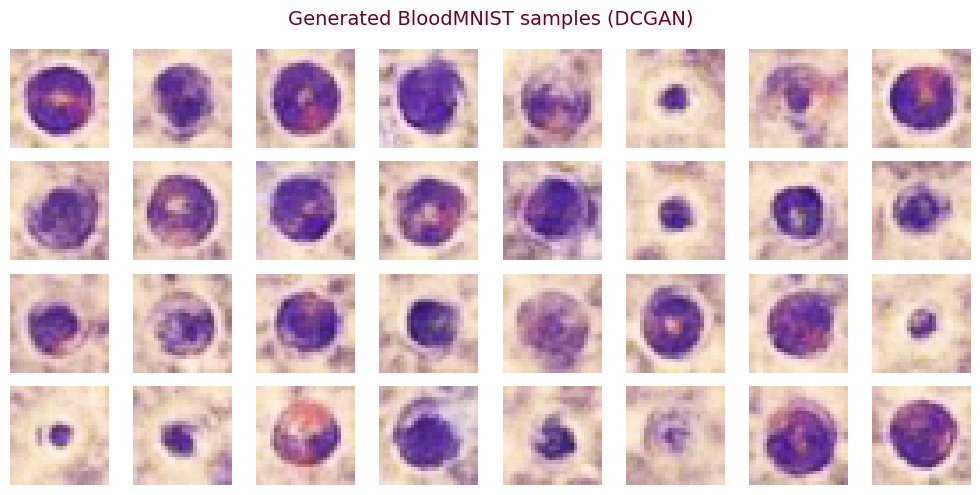

Pixel-space FID-like score: 39.968
(Lower is better; a full FID would use Inception-v3 features.)


In [13]:
# Step 4D: Visualise generated BloodMNIST samples + lightweight FID-style check
G_blood.eval()
with torch.no_grad():
    fake_grid = G_blood(fixed_noise).cpu()

fig, axes = plt.subplots(4, 8, figsize=(10, 5))
for ax, img in zip(axes.flat, fake_grid):
    ax.imshow(((img.permute(1, 2, 0).numpy() + 1) / 2).clip(0, 1))
    ax.axis('off')
plt.suptitle("Generated BloodMNIST samples (DCGAN)", fontsize=14, color="#720026")
plt.tight_layout()
plt.show()

# Lightweight FID-style check: compare mean/cov of real vs fake pixel stats
# (A full FID uses Inception features; we approximate with raw-pixel stats so the
# notebook stays self-contained.)
import numpy as np
with torch.no_grad():
    real_flat = torch.stack([img for img, _ in list(train_ds)[:1000]]).view(1000, -1).numpy()
    z = torch.randn(1000, nz, 1, 1, device=device)
    fake_flat = G_blood(z).cpu().view(1000, -1).numpy()

mu_r, mu_f = real_flat.mean(0), fake_flat.mean(0)
cov_r = np.cov(real_flat, rowvar=False)
cov_f = np.cov(fake_flat, rowvar=False)
from scipy.linalg import sqrtm
diff = mu_r - mu_f
covmean, _ = sqrtm(cov_r.dot(cov_f), disp=False)
if np.iscomplexobj(covmean):
    covmean = covmean.real
fid_like = float(diff.dot(diff) + np.trace(cov_r + cov_f - 2*covmean))
print(colored(f"Pixel-space FID-like score: {fid_like:.3f}", 'cyan', attrs=['bold']))
print(colored("(Lower is better; a full FID would use Inception-v3 features.)", 'yellow'))


## Step 5: CICIDS-2017 Tabular GAN (Part 2.2)

*Department of Data Science, UOH*
---

Now the modality shifts from images to **tabular network-traffic data**. We use the Wednesday capture from the CICIDS-2017 dataset (Sharafaldin et al., 2018), which contains BENIGN traffic and DoS attack variants. We clean, normalise, and feed the numeric features into a fully-connected GAN. Evaluation uses 2D PCA and t-SNE to compare the distributions of real and synthetic samples.


In [14]:
# Step 5A: Load & clean CICIDS-2017 Wednesday
import pandas as pd
import numpy as np
import torch
from termcolor import colored

CSV = "Wednesday-workingHours.pcap_ISCX.csv"
df = pd.read_csv(CSV)
df.columns = [c.strip() for c in df.columns]
print(colored(f"Rows: {len(df):,}  Cols: {df.shape[1]}", 'cyan'))
print(colored(f"Label counts:\n{df['Label'].value_counts()}", 'magenta'))

# Keep numeric features only; drop inf/NaN rows
num_df = df.select_dtypes(include=[np.number]).copy()
num_df = num_df.replace([np.inf, -np.inf], np.nan).dropna()
# Cap to 20k rows to keep training tractable on a laptop
num_df = num_df.sample(n=min(20000, len(num_df)), random_state=7).reset_index(drop=True)

# Min-max normalise to [-1, 1] to match Tanh output
feat = num_df.values.astype(np.float32)
f_min = feat.min(axis=0)
f_max = feat.max(axis=0)
scale = (f_max - f_min)
scale[scale == 0] = 1.0
feat_norm = 2 * (feat - f_min) / scale - 1.0
print(colored(f"Normalised feature matrix: {feat_norm.shape}", 'green'))
n_features = feat_norm.shape[1]


Rows: 692,703  Cols: 79
Label counts:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64
Normalised feature matrix: (20000, 78)


In [15]:
# Step 5B: Tabular Generator & Discriminator
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class TabGenerator(nn.Module):
    def __init__(self, z_dim=32, hidden=128, out_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden), nn.ELU(),
            nn.Linear(hidden, hidden), nn.ELU(),
            nn.Linear(hidden, out_dim), nn.Tanh()
        )
    def forward(self, z):
        return self.net(z)

class TabDiscriminator(nn.Module):
    def __init__(self, in_dim=10, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

z_dim_tab = 32
G_tab = TabGenerator(z_dim_tab, 128, n_features).to(device)
D_tab = TabDiscriminator(n_features, 128).to(device)
print(colored("Tabular Generator:", 'green', attrs=['bold'])); print(G_tab)
print(colored("Tabular Discriminator:", 'blue', attrs=['bold'])); print(D_tab)

tab_loader = DataLoader(
    TensorDataset(torch.tensor(feat_norm)),
    batch_size=256, shuffle=True, drop_last=True
)


Tabular Generator:
TabGenerator(
  (net): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=128, out_features=78, bias=True)
    (5): Tanh()
  )
)
Tabular Discriminator:
TabDiscriminator(
  (net): Sequential(
    (0): Linear(in_features=78, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=128, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


Epoch   1 D_loss=1.2701 G_loss=0.5728
Epoch   5 D_loss=1.2706 G_loss=0.7418
Epoch  10 D_loss=1.1851 G_loss=0.9251
Epoch  15 D_loss=1.1420 G_loss=0.8216
Epoch  20 D_loss=1.2129 G_loss=0.7755
Epoch  25 D_loss=1.0419 G_loss=1.0376
Epoch  30 D_loss=1.1364 G_loss=0.8218
Epoch  35 D_loss=1.1144 G_loss=0.9586
Epoch  40 D_loss=1.1772 G_loss=0.7725
Tabular GAN training complete.


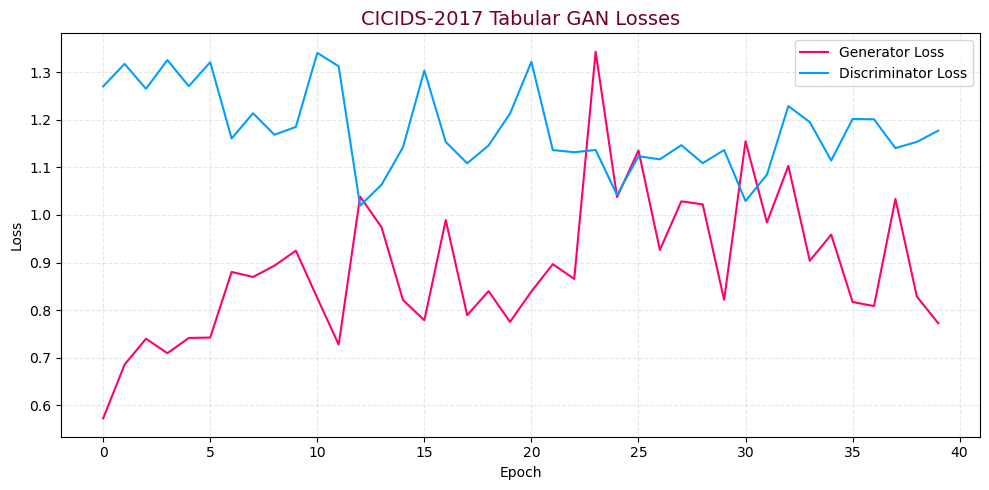

In [16]:
# Step 5C: Train the tabular GAN
import torch.optim as optim

criterion = nn.BCELoss()
optG = optim.Adam(G_tab.parameters(), lr=2e-4, betas=(0.5, 0.999))
optD = optim.Adam(D_tab.parameters(), lr=2e-4, betas=(0.5, 0.999))

num_epochs_tab = 40
G_losses_tab, D_losses_tab = [], []

for epoch in range(1, num_epochs_tab + 1):
    for (real_batch,) in tab_loader:
        real_batch = real_batch.to(device)
        b_size = real_batch.size(0)
        real_lab = torch.ones(b_size, 1, device=device)
        fake_lab = torch.zeros(b_size, 1, device=device)

        # Discriminator
        optD.zero_grad()
        d_real = D_tab(real_batch)
        loss_real = criterion(d_real, real_lab)
        z = torch.randn(b_size, z_dim_tab, device=device)
        fake = G_tab(z)
        d_fake = D_tab(fake.detach())
        loss_fake = criterion(d_fake, fake_lab)
        D_loss = loss_real + loss_fake
        D_loss.backward(); optD.step()

        # Generator
        optG.zero_grad()
        d_fake2 = D_tab(fake)
        G_loss = criterion(d_fake2, real_lab)
        G_loss.backward(); optG.step()

    G_losses_tab.append(G_loss.item())
    D_losses_tab.append(D_loss.item())
    if epoch % 5 == 0 or epoch == 1:
        print(colored(f"Epoch {epoch:3d}", 'cyan'),
              colored(f"D_loss={D_loss.item():.4f}", 'magenta'),
              colored(f"G_loss={G_loss.item():.4f}", 'yellow'))

print(colored("Tabular GAN training complete.", 'green', attrs=['bold']))

plt.figure(figsize=(10, 5))
plt.plot(G_losses_tab, label='Generator Loss', color='#ff006e')
plt.plot(D_losses_tab, label='Discriminator Loss', color='#009ffd')
plt.title("CICIDS-2017 Tabular GAN Losses", fontsize=14, color="#720026")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Running t-SNE (may take a minute)...


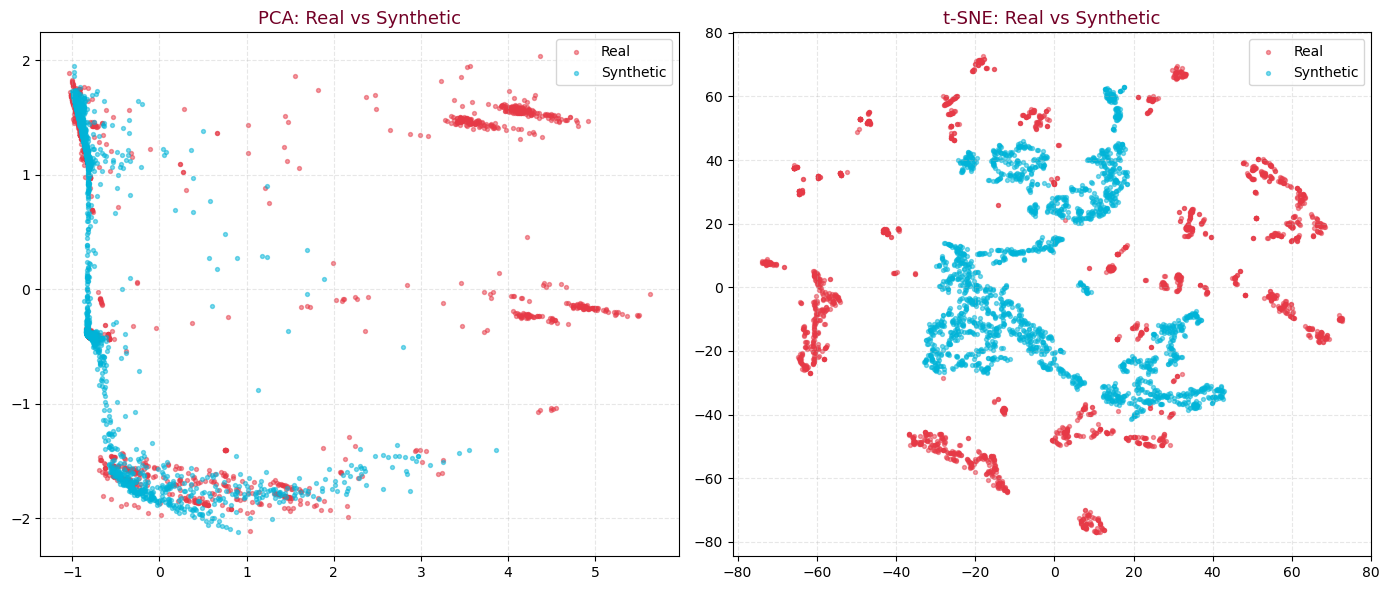

In [17]:
# Step 5D: PCA & t-SNE comparison — real vs synthetic
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

G_tab.eval()
with torch.no_grad():
    z = torch.randn(2000, z_dim_tab, device=device)
    fake = G_tab(z).cpu().numpy()

real_sample = feat_norm[np.random.choice(len(feat_norm), 2000, replace=False)]
combined = np.vstack([real_sample, fake])
labels = np.array(['Real'] * 2000 + ['Synthetic'] * 2000)

# PCA
pca = PCA(n_components=2)
pca_emb = pca.fit_transform(combined)

# t-SNE (a single fit over the combined cloud so coordinates are comparable)
print(colored("Running t-SNE (may take a minute)...", 'yellow'))
tsne = TSNE(n_components=2, perplexity=30, random_state=7, init='pca')
tsne_emb = tsne.fit_transform(combined)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for lab, colr in zip(['Real', 'Synthetic'], ['#e63946', '#00b4d8']):
    mask = labels == lab
    axes[0].scatter(pca_emb[mask, 0], pca_emb[mask, 1], s=8, alpha=0.5, label=lab, color=colr)
    axes[1].scatter(tsne_emb[mask, 0], tsne_emb[mask, 1], s=8, alpha=0.5, label=lab, color=colr)
axes[0].set_title("PCA: Real vs Synthetic", fontsize=13, color="#720026")
axes[1].set_title("t-SNE: Real vs Synthetic", fontsize=13, color="#720026")
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


## Step 6: QuickDraw 'Pizza' DCGAN (Part 2.3)

*Department of Data Science, UOH*
---

For the final application we train a grayscale DCGAN on sketches from Google's **QuickDraw** dataset. Each image is a 28x28 hand-drawn sketch of a pizza, pre-flattened as uint8 bitmaps in the official `.npy` format (Ha & Eck, 2018). The architecture mirrors Step 4 but with a single input channel.


Pizza sketches: (130371, 784)


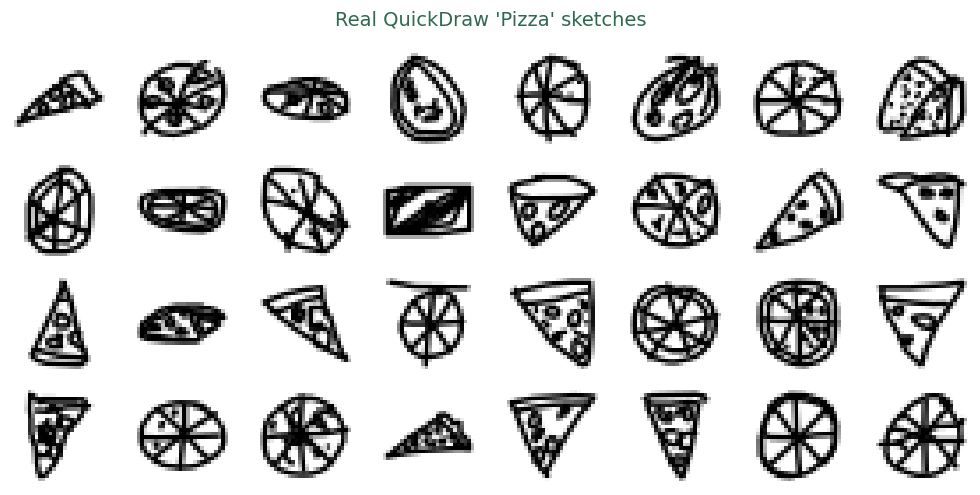

In [18]:
# Step 6A: Download pizza sketches & build a DataLoader
import os, urllib.request
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from termcolor import colored

URL = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/pizza.npy"
LOCAL = "pizza.npy"
if not os.path.exists(LOCAL):
    print(colored("Downloading QuickDraw 'pizza' sketches...", 'yellow'))
    urllib.request.urlretrieve(URL, LOCAL)

sketches = np.load(LOCAL)  # shape (N, 784) uint8
print(colored(f"Pizza sketches: {sketches.shape}", 'green'))
sketches = sketches[:20000]  # keep 20k for laptop-friendly training
pizza = sketches.astype(np.float32).reshape(-1, 1, 28, 28)
pizza = (pizza / 127.5) - 1.0  # scale to [-1, 1] for Tanh

pizza_loader = DataLoader(
    TensorDataset(torch.tensor(pizza)), batch_size=128, shuffle=True, drop_last=True
)

# Peek at real sketches
import matplotlib.pyplot as plt
real_batch = next(iter(pizza_loader))[0]
fig, axes = plt.subplots(4, 8, figsize=(10, 5))
for ax, img in zip(axes.flat, real_batch):
    ax.imshow(((img[0].numpy() + 1) / 2).clip(0, 1), cmap='gray_r')
    ax.axis('off')
plt.suptitle("Real QuickDraw 'Pizza' sketches", fontsize=14, color="#2d6a4f")
plt.tight_layout()
plt.show()


In [19]:
# Step 6B: DCGAN for 28x28 grayscale sketches (reusing the BloodMNIST blueprint)
import torch.nn as nn

nz_p = 100
ngf_p = 64
ndf_p = 64
nc_p = 1

class PizzaGenerator(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*4, 7, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(z)

class PizzaDiscriminator(nn.Module):
    def __init__(self, nc=1, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*2, 1, 7, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).view(-1, 1)

G_pizza = PizzaGenerator(nz_p, ngf_p, nc_p).to(device)
D_pizza = PizzaDiscriminator(nc_p, ndf_p).to(device)
G_pizza.apply(dcgan_init)
D_pizza.apply(dcgan_init)
print(colored("Pizza-DCGAN Generator:", 'green', attrs=['bold'])); print(G_pizza)
print(colored("Pizza-DCGAN Discriminator:", 'blue', attrs=['bold'])); print(D_pizza)


Pizza-DCGAN Generator:
PizzaGenerator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
)
Pizza-DCGAN Discriminator:
PizzaDiscriminator(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(ne

Epoch   1 D_loss=0.7713 G_loss=0.9934
Epoch   2 D_loss=0.3707 G_loss=2.4082
Epoch   4 D_loss=0.2440 G_loss=2.3657
Epoch   6 D_loss=0.2387 G_loss=3.2187
Epoch   8 D_loss=0.2027 G_loss=3.0743
Epoch  10 D_loss=0.2050 G_loss=2.8409
Epoch  12 D_loss=0.1834 G_loss=3.5482
Epoch  14 D_loss=0.1227 G_loss=3.1850
Epoch  16 D_loss=0.2353 G_loss=2.5350
Epoch  18 D_loss=0.0993 G_loss=3.4236
Epoch  20 D_loss=0.2190 G_loss=2.2061
Epoch  22 D_loss=0.1134 G_loss=3.1932
Epoch  24 D_loss=0.0546 G_loss=4.3301
Pizza DCGAN training complete.


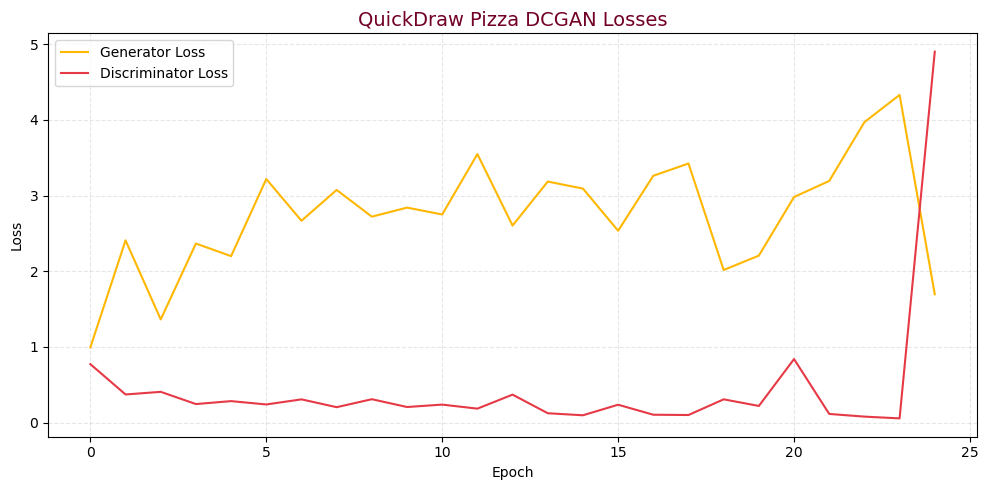

In [20]:
# Step 6C: Train the pizza DCGAN
import torch.optim as optim

criterion = nn.BCELoss()
optG = optim.Adam(G_pizza.parameters(), lr=2e-4, betas=(0.5, 0.999))
optD = optim.Adam(D_pizza.parameters(), lr=2e-4, betas=(0.5, 0.999))

num_epochs_pizza = 25
fixed_noise_p = torch.randn(32, nz_p, 1, 1, device=device)
G_losses_pizza, D_losses_pizza = [], []

for epoch in range(1, num_epochs_pizza + 1):
    for (real_imgs,) in pizza_loader:
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)
        real_lab = torch.ones(b_size, 1, device=device)
        fake_lab = torch.zeros(b_size, 1, device=device)

        # Discriminator
        optD.zero_grad()
        d_real = D_pizza(real_imgs)
        loss_real = criterion(d_real, real_lab)
        z = torch.randn(b_size, nz_p, 1, 1, device=device)
        fake = G_pizza(z)
        d_fake = D_pizza(fake.detach())
        loss_fake = criterion(d_fake, fake_lab)
        D_loss = loss_real + loss_fake
        D_loss.backward(); optD.step()

        # Generator
        optG.zero_grad()
        d_fake2 = D_pizza(fake)
        G_loss = criterion(d_fake2, real_lab)
        G_loss.backward(); optG.step()

    G_losses_pizza.append(G_loss.item())
    D_losses_pizza.append(D_loss.item())
    if epoch % 2 == 0 or epoch == 1:
        print(colored(f"Epoch {epoch:3d}", 'cyan'),
              colored(f"D_loss={D_loss.item():.4f}", 'magenta'),
              colored(f"G_loss={G_loss.item():.4f}", 'yellow'))

print(colored("Pizza DCGAN training complete.", 'green', attrs=['bold']))

plt.figure(figsize=(10, 5))
plt.plot(G_losses_pizza, label='Generator Loss', color='#ffb700')
plt.plot(D_losses_pizza, label='Discriminator Loss', color='#e63946')
plt.title("QuickDraw Pizza DCGAN Losses", fontsize=14, color="#720026")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


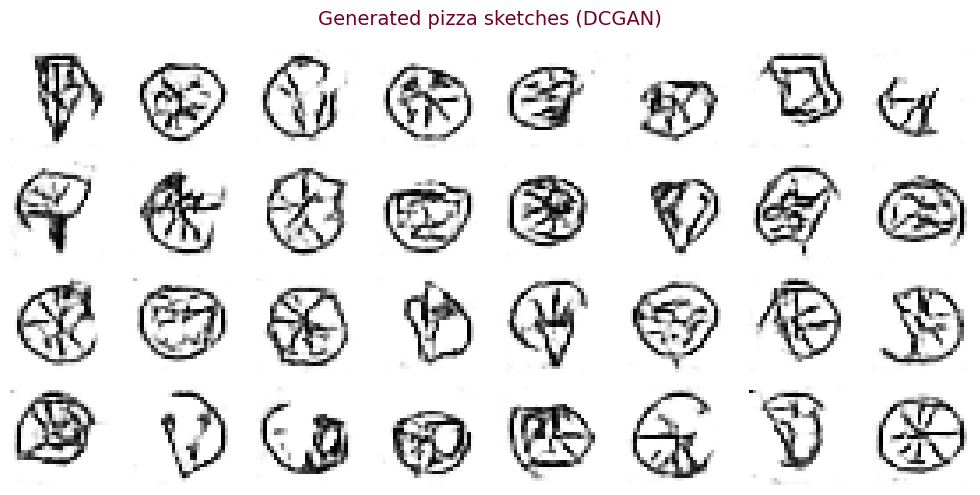

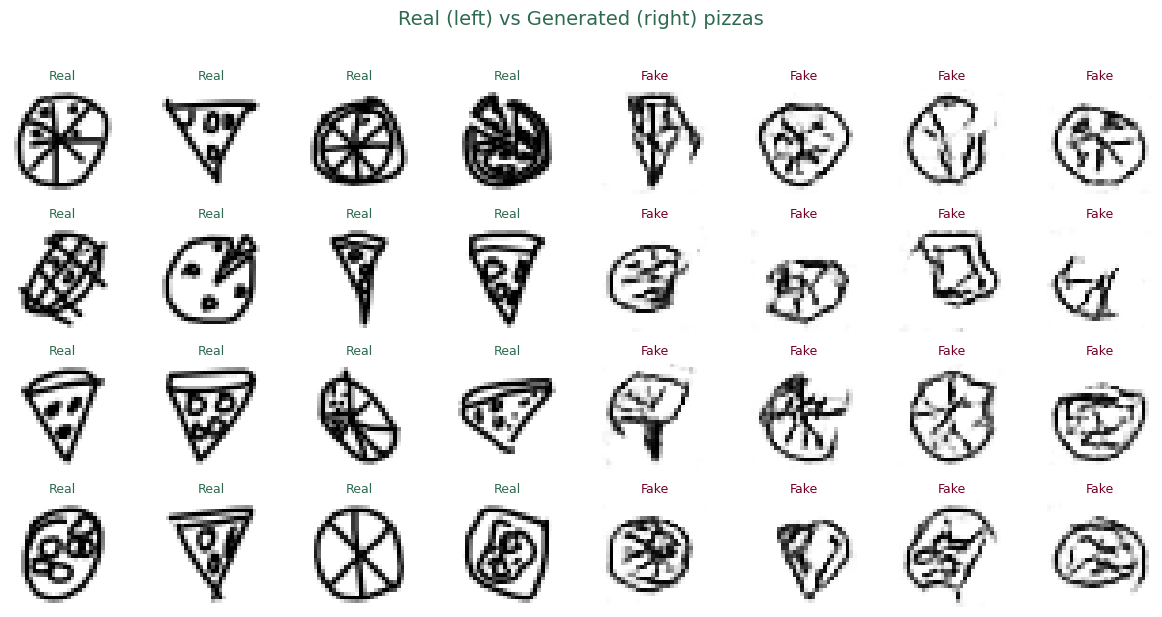

Pixel-space FID-like score (pizza): 215.773


In [21]:
# Step 6D: Sample fake pizzas & comparison grid
G_pizza.eval()
with torch.no_grad():
    fake_pizzas = G_pizza(fixed_noise_p).cpu()

fig, axes = plt.subplots(4, 8, figsize=(10, 5))
for ax, img in zip(axes.flat, fake_pizzas):
    ax.imshow(((img[0].numpy() + 1) / 2).clip(0, 1), cmap='gray_r')
    ax.axis('off')
plt.suptitle("Generated pizza sketches (DCGAN)", fontsize=14, color="#720026")
plt.tight_layout()
plt.show()

# Side-by-side real vs generated for qualitative comparison
real_sample = next(iter(pizza_loader))[0][:16]
fake_sample = fake_pizzas[:16]

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i in range(16):
    ax = axes[i // 4, (i % 4)]
    ax.imshow(((real_sample[i, 0].numpy() + 1) / 2).clip(0, 1), cmap='gray_r')
    ax.set_title("Real", color="#2d6a4f", fontsize=9)
    ax.axis('off')
    ax2 = axes[i // 4, 4 + (i % 4)]
    ax2.imshow(((fake_sample[i, 0].numpy() + 1) / 2).clip(0, 1), cmap='gray_r')
    ax2.set_title("Fake", color="#720026", fontsize=9)
    ax2.axis('off')
plt.suptitle("Real (left) vs Generated (right) pizzas", fontsize=14, color="#2d6a4f", y=1.02)
plt.tight_layout()
plt.show()

# Lightweight FID-style check in pixel space
from scipy.linalg import sqrtm
real_flat = real_batch.view(real_batch.size(0), -1).numpy()[:1000]
z = torch.randn(1000, nz_p, 1, 1, device=device)
with torch.no_grad():
    fake_flat = G_pizza(z).cpu().view(1000, -1).numpy()
mu_r, mu_f = real_flat.mean(0), fake_flat.mean(0)
cov_r = np.cov(real_flat, rowvar=False)
cov_f = np.cov(fake_flat, rowvar=False)
diff = mu_r - mu_f
covmean, _ = sqrtm(cov_r.dot(cov_f), disp=False)
if np.iscomplexobj(covmean):
    covmean = covmean.real
fid_like = float(diff.dot(diff) + np.trace(cov_r + cov_f - 2*covmean))
print(colored(f"Pixel-space FID-like score (pizza): {fid_like:.3f}", 'cyan', attrs=['bold']))
